In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
model = CNN(width=4, bn=True, normalise=False)
device = torch.device("mps")
weights_path = TRAINING_RESULTS/'run_120426_013831'/'best_model_weights.pth'
#weights_path = TRAINING_RESULTS/'high_mass'/ 'good_runs' /'run_110426_011734'/'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(2, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=8192, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Plotter

In [37]:
results_path = TRAINING_RESULTS/'low_mass'/ 'good_runs' /'run_090326_165434'/'results.pt'
results = torch.load(results_path)
iters, train_loss, train_soft_acc, val_soft_acc,\
          train_hard_acc, val_hard_acc, test_soft_acc, test_hard_acc= results

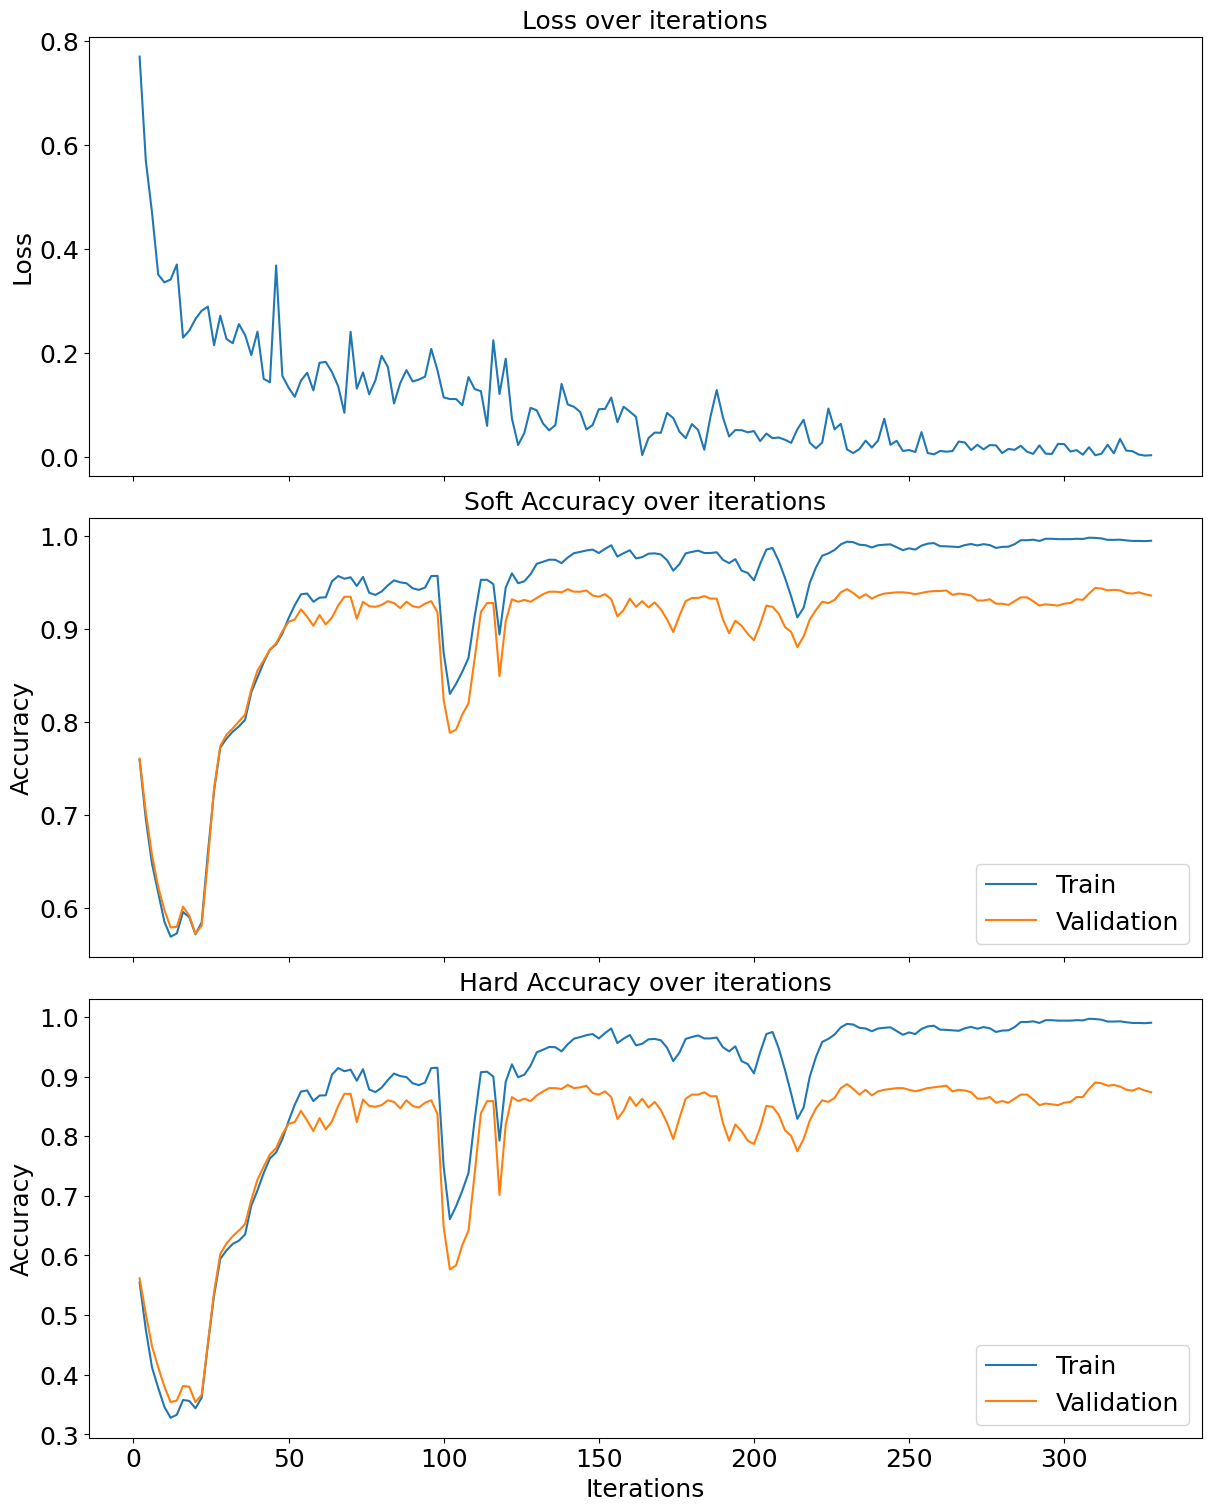

In [38]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 15), constrained_layout=True)

axes[0].plot(iters[:len(train_loss)], train_loss)
axes[0].set_title("Loss over iterations",  fontsize=18)
axes[0].set_ylabel("Loss",  fontsize=18)
axes[0].tick_params(axis='y', labelsize=18)

axes[1].plot(iters[:len(train_soft_acc)], train_soft_acc)
axes[1].plot(iters[:len(val_soft_acc)], val_soft_acc)
axes[1].set_title("Soft Accuracy over iterations", fontsize=18)
axes[1].set_ylabel("Accuracy",  fontsize=18)
axes[1].legend(["Train", "Validation"],  fontsize=18)
axes[1].tick_params(axis='y', labelsize=18)

axes[2].plot(iters[:len(train_hard_acc)], train_hard_acc)
axes[2].plot(iters[:len(val_hard_acc)], val_hard_acc)
axes[2].set_title("Hard Accuracy over iterations",  fontsize=18)
axes[2].set_xlabel("Iterations",  fontsize=18)
axes[2].set_ylabel("Accuracy",  fontsize=18)
axes[2].legend(["Train", "Validation"],  fontsize=18)

axes[2].tick_params(axis='x', labelsize=18)
axes[2].tick_params(axis='y', labelsize=18)
plt.show()

## Confusion matrix

In [3]:
DEVICE = torch.device("mps")
def accuracy(model, loader, threshold=0.5):
    model.eval()
    
    soft_correct, hard_correct, soft_total, hard_total = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            soft_correct += (predicted == labels).sum().item()
            hard_correct += ((predicted == labels).all(dim=1)).sum().item()
            soft_total += labels.numel()
            hard_total += labels.size(0)
    
    soft_acc = soft_correct/soft_total
    hard_acc = hard_correct/hard_total
    return soft_acc, hard_acc

In [6]:
dataset = LISADataset(training_dataset_path)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(42)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [7]:
val_loader = DataLoader(val_dataset, batch_size=64)
val_soft_acc, val_hard_acc = accuracy(model, val_loader)

test_loader = DataLoader(test_dataset, batch_size=64)
test_soft_acc, test_hard_acc = accuracy(model, test_loader)

print(f"Validation Soft Accuracy: {val_soft_acc:.4f}, Validation Hard Accuracy: {val_hard_acc:.4f}")
print(f"Test Soft Accuracy: {test_soft_acc:.4f}, Test Hard Accuracy: {test_hard_acc:.4f}")

Validation Soft Accuracy: 0.9539, Validation Hard Accuracy: 0.9093
Test Soft Accuracy: 0.9537, Test Hard Accuracy: 0.9089


In [8]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1].to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

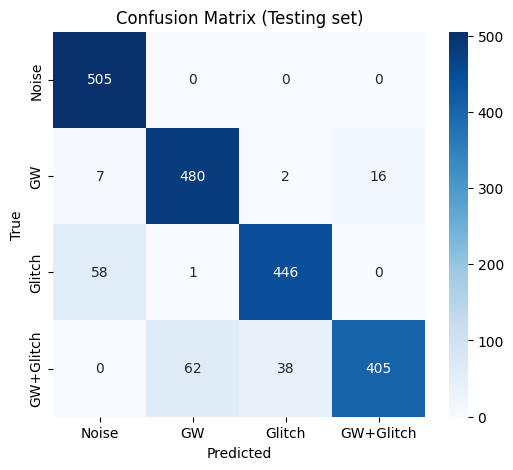

In [9]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [34]:
np.where((true_class == 3)&(pred_class == 1))[0]

array([1010, 1011, 1012, 1013, 1014, 1020, 1021, 1022, 1023, 1024, 1035,
       1037, 1039, 1049, 1099, 1100, 1101, 1102, 1105, 1110, 1111, 1112,
       1113, 1114, 1115, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1230,
       1254, 1269, 1325, 1326, 1327, 1328, 1329, 1343, 1354, 1375, 1398,
       1399, 1405, 1410, 1411, 1412, 1414, 1419, 1431, 1432, 1433, 1465,
       1466, 1467, 1475, 1476, 1477, 1478, 1479])

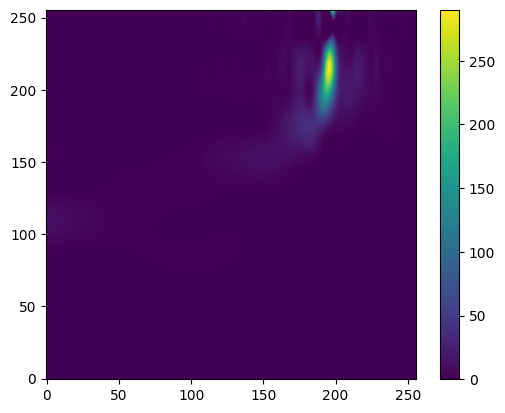

True label: tensor([1., 1.])
Sim index: 15
Time index: 0


In [38]:
image, label, sim_index, time_index = test_dataset[1020]
plt.imshow(image[1], origin='lower')
plt.colorbar()
plt.show()
print('True label:', label)
print('Sim index:', sim_index)
print('Time index:', time_index)

In [39]:
wrong = np.where((true_class == 3)&(pred_class == 1))[0]
sim_indices = [test_dataset[i][2] for i in wrong]
all_indices = [test_dataset[i][2] for i in range(len(test_dataset))]

In [41]:
sim_indices = np.unique(sim_indices)
with h5py.File(mixed_dataset_path, 'r') as f:
    amps = f['amp'][:]
    betas = f['beta'][:]
    inj_points = f['inj_point'][:]

wrong_amps = amps[sim_indices]
wrong_betas = betas[sim_indices]

all_amps = amps[all_indices]
all_betas = betas[all_indices]

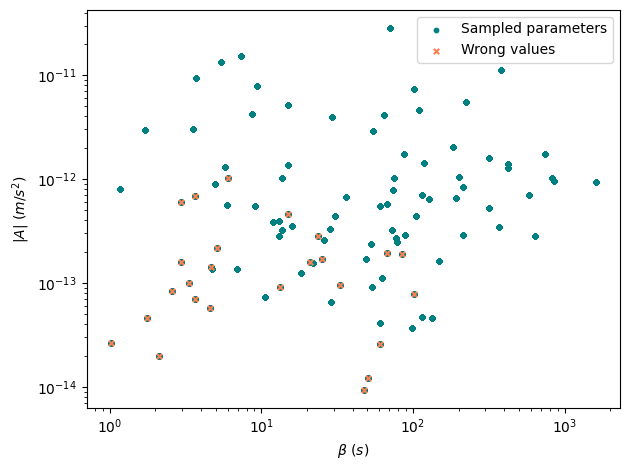

In [42]:
plt.figure(tight_layout=True)
plt.scatter(all_betas, all_amps, color='teal', s=10, label='Sampled parameters')
plt.scatter(wrong_betas, np.abs(wrong_amps), color='coral', s=15, marker='x', label='Wrong values')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$|A|\ (m/s^2)$')
plt.xlabel('$\\beta\ (s)$')
plt.legend()
plt.show()

## Time centering

In [18]:
with h5py.File(gw_hm_dataset_path, 'r') as f:
    X = f['X'][sim_index]
    Y = f['Y'][sim_index]
    Z = f['Z'][sim_index]

In [19]:
tcen_arr = np.linspace(-3, 3, 25)*3600

image_arr = np.zeros((len(tcen_arr), 256, 256, 3))
for i, tcen in enumerate(tcen_arr):
    args = (tcen, X, Y, Z)
    QT, tarr, farr = run_one_sample(args)
    image_arr[i, :, :, :] = QT

image_arr = torch.tensor(image_arr, dtype=torch.float32)
image_arr = image_arr.permute(0, 3, 1, 2)

In [20]:
with torch.no_grad():
    outputs = model(image_arr.to(device).contiguous())
    probs = torch.sigmoid(outputs)

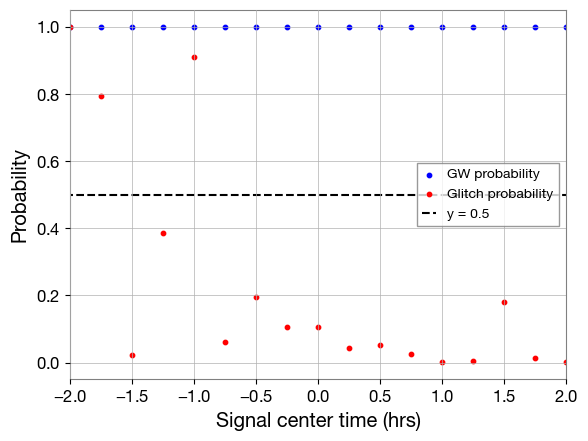

: 

In [ ]:
gw_prob = probs[:, 0].detach().cpu().numpy()
glitch_prob = probs[:, 1].detach().cpu().numpy()
tcen_act = 1.87*3600
plt.scatter(tcen_arr/3600, gw_prob, color='blue', label='GW probability', s=10)
plt.scatter(tcen_arr/3600, glitch_prob, color='red', label='Glitch probability', s=10)
plt.hlines(y=[0.5], xmin=-3, xmax=3, color='black', linestyle='dashed', label='y = 0.5')
plt.xlabel('Signal center time (hrs)')
plt.ylabel('Probability')
plt.legend(fontsize=10)
plt.xlim(-2,2)
#plt.ylim(-0.5, 1.2)
plt.show()